# SOLWEIG route analysis: MRT, UTCI, and JOS-3 core-temperature rise

This notebook analyzes the **geometry only** of the three uploaded routes. Existing MRT/UTCI attributes stored in the GeoJSON are deliberately ignored.

The workflow:

1. Load the three routes from GeoJSON.
2. Reproject them from CRS84 (`longitude, latitude`) to the SOLWEIG raster CRS.
3. Resample each route at a regular spacing.
4. Assign travel time using a 13:00 departure and 1.3 m/s walking speed.
5. Sample SOLWEIG MRT and UTCI GeoTIFFs with temporal interpolation.
6. Interpolate air temperature, RH, and wind from the SOLWEIG weather forcing.
7. Run an independent JOS-3 simulation along each route.
8. Export pointwise CSV/GeoJSON results, route summaries, and comparison plots.

Default comparison settings:

- Date: July 6
- Departure: 13:00 local time
- Walking speed: 1.3 m/s
- Body: male, 32 years, 1.73 m, 55 kg
- Clothing: 0.5 clo
- Physical activity ratio: 2.0

Review the physiological assumptions before publication.


> **Correction included:** SOLWEIG TMY output years are normalized to the route comparison year before temporal interpolation. Out-of-range times now raise an error instead of silently selecting the first or last raster.


The notebook also exports `routes_points_solweig.csv` in the same column format as the reference `route_utci` workflow for direct MRT and UTCI validation.


## 1. Install required packages

In [30]:
%pip install -q pandas numpy rasterio pyproj shapely matplotlib pythermalcomfort

/usr/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=935644) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


Note: you may need to restart the kernel to use updated packages.


Restart the kernel once if packages were newly installed, then run from the next cell.

## 2. Imports and paths

In [31]:
from pathlib import Path
from datetime import datetime, timedelta
import json
import re
import warnings

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

from pyproj import CRS, Transformer
from shapely.geometry import shape, LineString, mapping
from shapely.ops import transform as shapely_transform
from pythermalcomfort.models import JOS3

warnings.filterwarnings("once")

In [32]:
BASE = Path("/media/harshin/data_drive/solweig")

# Place the uploaded routes.geojson at this path.
ROUTES_PATH = BASE / "routes.geojson"

# SOLWEIG outputs created by the previous notebook....
SOLWEIG_OUTPUT_DIR = BASE / "solweig_output_2025-07-06"

# Optional weather table produced in the SOLWEIG notebook.
# If absent, fallback RH/wind and air temperature extracted from metadata/files
# will be used where possible.
WEATHER_CSV = BASE / "weather" / "weather.csv"

OUTPUT_DIR = BASE / "route_results_solweig"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEPARTURE_LOCAL = pd.Timestamp("2025-07-06 13:00:00")
WALKING_SPEED_MS = 1.3
ROUTE_SAMPLE_SPACING_M = 1.0

# Meteorological fallbacks
FALLBACK_RH_PCT = 70.0
FALLBACK_WIND_MS = 3.1
FALLBACK_AIR_TEMP_C = 31.0

# JOS-3 body and activity assumptions
BODY_HEIGHT_M = 1.73
BODY_WEIGHT_KG = 55.0
BODY_AGE_YR = 32
BODY_SEX = "male"
BODY_FAT_PCT = 15.0
CLO = 0.5
PAR = 2.0

# Preconditioning ensures all three routes start from an identical physiological state.
PRECONDITION_MIN = 30
PRECONDITION_TDB_C = 26.0
PRECONDITION_TR_C = 26.0
PRECONDITION_RH_PCT = 50.0
PRECONDITION_V_MS = 0.1
PRECONDITION_PAR = 1.2

print("Routes:", ROUTES_PATH, ROUTES_PATH.exists())
print("SOLWEIG output:", SOLWEIG_OUTPUT_DIR, SOLWEIG_OUTPUT_DIR.exists())

Routes: /media/harshin/data_drive/solweig/routes.geojson True
SOLWEIG output: /media/harshin/data_drive/solweig/solweig_output_2025-07-06 True


## 3. Load route geometry only

In [33]:
if not ROUTES_PATH.exists():
    raise FileNotFoundError(
        f"Copy routes.geojson to {ROUTES_PATH} before continuing."
    )

route_doc = json.loads(ROUTES_PATH.read_text())

source_crs_name = (
    route_doc.get("crs", {})
    .get("properties", {})
    .get("name", "OGC:CRS84")
)
source_crs = CRS.from_user_input(source_crs_name)

routes = []
for i, feature in enumerate(route_doc["features"], start=1):
    geom = shape(feature["geometry"])
    if not isinstance(geom, LineString):
        raise TypeError(f"Feature {i} is not a LineString.")

    # Deliberately ignore all pre-existing simulation metrics.
    route_id = feature.get("properties", {}).get("route_id", i)
    routes.append({"route_id": int(route_id), "geometry_wgs84": geom})

print("Source CRS:", source_crs)
print("Routes loaded:", len(routes))
for route in routes:
    print(
        "Route",
        route["route_id"],
        "vertices:",
        len(route["geometry_wgs84"].coords),
    )

Source CRS: urn:ogc:def:crs:OGC:1.3:CRS84
Routes loaded: 3
Route 1 vertices: 2092
Route 2 vertices: 1849
Route 3 vertices: 1965


## 4. Find SOLWEIG MRT and UTCI GeoTIFFs

In [34]:
all_tifs = sorted(SOLWEIG_OUTPUT_DIR.rglob("*.tif"))

tmrt_paths = [
    p for p in all_tifs
    if "tmrt" in p.name.lower()
    and not any(k in p.name.lower() for k in ["mean", "max", "min"])
]
utci_paths = [
    p for p in all_tifs
    if "utci" in p.name.lower()
    and not any(k in p.name.lower() for k in ["mean", "max", "min", "hours"])
]

print("Per-timestep MRT files:", len(tmrt_paths))
print("Per-timestep UTCI files:", len(utci_paths))

print("\nExample MRT files:")
for p in tmrt_paths[:5]:
    print(" ", p.relative_to(SOLWEIG_OUTPUT_DIR))

print("\nExample UTCI files:")
for p in utci_paths[:5]:
    print(" ", p.relative_to(SOLWEIG_OUTPUT_DIR))

if not tmrt_paths:
    raise FileNotFoundError(
        "No per-timestep MRT GeoTIFFs found. Confirm that SOLWEIG was run "
        'with outputs=["tmrt", "utci", "shadow"].'
    )
if not utci_paths:
    raise FileNotFoundError(
        "No per-timestep UTCI GeoTIFFs found. Confirm that SOLWEIG was run "
        'with outputs=["tmrt", "utci", "shadow"].'
    )

Per-timestep MRT files: 24
Per-timestep UTCI files: 24

Example MRT files:
  tmrt/tmrt_20130706_0000.tif
  tmrt/tmrt_20130706_0100.tif
  tmrt/tmrt_20130706_0200.tif
  tmrt/tmrt_20130706_0300.tif
  tmrt/tmrt_20130706_0400.tif

Example UTCI files:
  utci/utci_20130706_0000.tif
  utci/utci_20130706_0100.tif
  utci/utci_20130706_0200.tif
  utci/utci_20130706_0300.tif
  utci/utci_20130706_0400.tif


## 5. Parse timestamps from SOLWEIG filenames

In [35]:
def parse_timestamp_from_name(path):
    """Parse common SOLWEIG timestamp filename patterns."""
    text = Path(path).stem

    patterns = [
        # YYYYMMDD_HHMM or YYYYMMDD-HHMM
        (r"(?P<date>\d{8})[_-](?P<time>\d{4})", "%Y%m%d%H%M"),

        # YYYY-MM-DD_HH-MM or YYYY-MM-DD_HHMM
        (
            r"(?P<y>\d{4})-(?P<m>\d{2})-(?P<d>\d{2})"
            r"[_T-](?P<h>\d{2})[-:]?(?P<mi>\d{2})",
            None,
        ),

        # MMDD_HHMM, useful for TMY output
        (r"(?<!\d)(?P<md>\d{4})[_-](?P<time>\d{4})(?!\d)", None),
    ]

    match = re.search(patterns[0][0], text)
    if match:
        return pd.to_datetime(
            match.group("date") + match.group("time"),
            format=patterns[0][1],
        )

    match = re.search(patterns[1][0], text)
    if match:
        return pd.Timestamp(
            year=int(match.group("y")),
            month=int(match.group("m")),
            day=int(match.group("d")),
            hour=int(match.group("h")),
            minute=int(match.group("mi")),
        )

    match = re.search(patterns[2][0], text)
    if match:
        md = match.group("md")
        hhmm = match.group("time")
        return pd.Timestamp(
            year=DEPARTURE_LOCAL.year,
            month=int(md[:2]),
            day=int(md[2:]),
            hour=int(hhmm[:2]),
            minute=int(hhmm[2:]),
        )

    return pd.NaT


def build_raster_catalog(paths, variable):
    records = [
        {
            "variable": variable,
            "time": parse_timestamp_from_name(path),
            "path": Path(path),
        }
        for path in paths
    ]

    catalog = pd.DataFrame(records)
    missing = catalog["time"].isna()

    if missing.any():
        print(f"\nCould not parse {missing.sum()} {variable} filenames:")
        for path in catalog.loc[missing, "path"].head(20):
            print(" ", path.name)

    return (
        catalog
        .dropna(subset=["time"])
        .sort_values("time")
        .drop_duplicates("time", keep="first")
        .reset_index(drop=True)
    )


def normalize_catalog_to_run_date(catalog, target_date):
    """
    Replace the TMY/EPW source year with the comparison-run year while
    preserving month, day, hour, minute, and second.
    """
    catalog = catalog.copy()
    target_date = pd.Timestamp(target_date)

    catalog["source_time"] = catalog["time"]
    catalog["time"] = catalog["time"].apply(
        lambda t: pd.Timestamp(
            year=target_date.year,
            month=t.month,
            day=t.day,
            hour=t.hour,
            minute=t.minute,
            second=t.second,
        )
    )

    return (
        catalog
        .sort_values("time")
        .drop_duplicates("time", keep="first")
        .reset_index(drop=True)
    )


tmrt_catalog = build_raster_catalog(tmrt_paths, "tmrt")
utci_catalog = build_raster_catalog(utci_paths, "utci")

if tmrt_catalog.empty or utci_catalog.empty:
    raise RuntimeError(
        "Timestamp parsing failed. Inspect the printed filenames and add their "
        "pattern to parse_timestamp_from_name()."
    )

# Critical correction: SOLWEIG TMY files may retain a source year such as 2013,
# while the route comparison is defined for 2025. Normalize both catalogs.
tmrt_catalog = normalize_catalog_to_run_date(
    tmrt_catalog,
    DEPARTURE_LOCAL,
)
utci_catalog = normalize_catalog_to_run_date(
    utci_catalog,
    DEPARTURE_LOCAL,
)

print("\nMRT catalog:")
display(tmrt_catalog[["source_time", "time", "path"]].head())
print("MRT normalized range:", tmrt_catalog["time"].min(), "to", tmrt_catalog["time"].max())

print("\nUTCI catalog:")
display(utci_catalog[["source_time", "time", "path"]].head())
print("UTCI normalized range:", utci_catalog["time"].min(), "to", utci_catalog["time"].max())

# Verify that the requested departure time maps to the intended hour.
mrt_exact = tmrt_catalog.loc[tmrt_catalog["time"] == DEPARTURE_LOCAL]
utci_exact = utci_catalog.loc[utci_catalog["time"] == DEPARTURE_LOCAL]

print("\nDeparture-time raster check:")
print(
    "MRT:",
    mrt_exact.iloc[0]["path"].name if not mrt_exact.empty else "no exact match",
)
print(
    "UTCI:",
    utci_exact.iloc[0]["path"].name if not utci_exact.empty else "no exact match",
)



MRT catalog:


,source_time,time,path
0,2013-07-06 00:00:00,2025-07-06 00:00:00,/media/harshin/data_drive/solweig/solweig_outp...
1,2013-07-06 01:00:00,2025-07-06 01:00:00,/media/harshin/data_drive/solweig/solweig_outp...
2,2013-07-06 02:00:00,2025-07-06 02:00:00,/media/harshin/data_drive/solweig/solweig_outp...
3,2013-07-06 03:00:00,2025-07-06 03:00:00,/media/harshin/data_drive/solweig/solweig_outp...
4,2013-07-06 04:00:00,2025-07-06 04:00:00,/media/harshin/data_drive/solweig/solweig_outp...


MRT normalized range: 2025-07-06 00:00:00 to 2025-07-06 23:00:00

UTCI catalog:


,source_time,time,path
0,2013-07-06 00:00:00,2025-07-06 00:00:00,/media/harshin/data_drive/solweig/solweig_outp...
1,2013-07-06 01:00:00,2025-07-06 01:00:00,/media/harshin/data_drive/solweig/solweig_outp...
2,2013-07-06 02:00:00,2025-07-06 02:00:00,/media/harshin/data_drive/solweig/solweig_outp...
3,2013-07-06 03:00:00,2025-07-06 03:00:00,/media/harshin/data_drive/solweig/solweig_outp...
4,2013-07-06 04:00:00,2025-07-06 04:00:00,/media/harshin/data_drive/solweig/solweig_outp...


UTCI normalized range: 2025-07-06 00:00:00 to 2025-07-06 23:00:00

Departure-time raster check:
MRT: tmrt_20130706_1300.tif
UTCI: utci_20130706_1300.tif


## 6. Reproject and resample the three routes

In [36]:
with rasterio.open(tmrt_catalog.iloc[0]["path"]) as src:
    raster_crs = src.crs
    raster_transform = src.transform
    raster_bounds = src.bounds
    raster_shape = src.shape

if raster_crs is None:
    raise ValueError("SOLWEIG raster has no CRS.")

transformer = Transformer.from_crs(
    source_crs,
    raster_crs,
    always_xy=True,
)

print("Raster CRS:", raster_crs)
print("Raster shape:", raster_shape)
print("Raster bounds:", raster_bounds)

def resample_line(line, spacing_m):
    length = line.length
    distances = np.arange(0.0, length, spacing_m)
    if len(distances) == 0 or distances[-1] < length:
        distances = np.append(distances, length)
    points = [line.interpolate(float(d)) for d in distances]
    return distances, points

route_point_tables = {}

for route in routes:
    route_id = route["route_id"]
    line_xy = shapely_transform(
        transformer.transform,
        route["geometry_wgs84"],
    )

    distances, points = resample_line(line_xy, ROUTE_SAMPLE_SPACING_M)
    elapsed_s = distances / WALKING_SPEED_MS
    timestamps = DEPARTURE_LOCAL + pd.to_timedelta(elapsed_s, unit="s")

    df = pd.DataFrame({
        "route_id": route_id,
        "point_index": np.arange(len(points)),
        "distance_m": distances,
        "elapsed_s": elapsed_s,
        "timestamp": timestamps,
        "x": [p.x for p in points],
        "y": [p.y for p in points],
    })
    route_point_tables[route_id] = df

    print(
        f"Route {route_id}: {line_xy.length:.1f} m, "
        f"{elapsed_s[-1] / 60:.2f} min, {len(df)} sampled points"
    )

Raster CRS: EPSG:6346
Raster shape: (406, 588)
Raster bounds: BoundingBox(left=562027.6875, bottom=2848417.0, right=563203.6875, top=2849229.0)
Route 1: 2086.5 m, 26.75 min, 2088 sampled points
Route 2: 1843.6 m, 23.64 min, 1845 sampled points
Route 3: 1960.6 m, 25.14 min, 1962 sampled points


## 7. Temporally interpolate raster values along each moving route

In [37]:
def nearest_time_bracket(catalog, target_time):
    """
    Return the surrounding raster times and interpolation weight.

    Unlike the earlier version, this function never silently clamps an
    out-of-range request to the first or last raster.
    """
    target_time = pd.Timestamp(target_time)
    start_time = catalog["time"].min()
    end_time = catalog["time"].max()

    if target_time < start_time or target_time > end_time:
        raise ValueError(
            f"Requested time {target_time} is outside the available raster "
            f"range {start_time} to {end_time}."
        )

    times = catalog["time"].to_numpy(dtype="datetime64[ns]")
    target = np.datetime64(target_time.to_datetime64())
    idx = np.searchsorted(times, target)

    # Exact match
    if idx < len(times) and times[idx] == target:
        row = catalog.iloc[idx]
        return row, row, 0.0

    if idx == 0 or idx >= len(catalog):
        raise ValueError(f"Could not bracket requested time {target_time}.")

    before = catalog.iloc[idx - 1]
    after = catalog.iloc[idx]

    interval_seconds = (after["time"] - before["time"]).total_seconds()
    if interval_seconds <= 0:
        raise ValueError("Raster catalog contains a non-positive time interval.")

    weight = (
        target_time - before["time"]
    ).total_seconds() / interval_seconds

    return before, after, float(weight)


# Show the exact raster mapping before sampling the routes.
test_before, test_after, test_weight = nearest_time_bracket(
    tmrt_catalog,
    DEPARTURE_LOCAL,
)
print("Requested departure:", DEPARTURE_LOCAL)
print("MRT before:", test_before["time"], test_before["path"].name)
print("MRT after: ", test_after["time"], test_after["path"].name)
print("Interpolation weight:", test_weight)


_raster_cache = {}

def sample_one_raster(path, coords):
    path = Path(path)
    key = str(path)

    if key not in _raster_cache:
        _raster_cache[key] = rasterio.open(path)

    src = _raster_cache[key]
    values = np.array([value[0] for value in src.sample(coords)], dtype=float)

    if src.nodata is not None:
        values[np.isclose(values, src.nodata)] = np.nan

    return values


def sample_time_varying_rasters(df, catalog):
    output = np.full(len(df), np.nan, dtype=float)

    groups = {}
    for row_position, timestamp in enumerate(df["timestamp"]):
        before, after, weight = nearest_time_bracket(catalog, timestamp)
        key = (
            str(before["path"]),
            str(after["path"]),
            round(weight, 8),
        )
        groups.setdefault(key, []).append(row_position)

    for (before_path, after_path, weight), positions in groups.items():
        coords = list(
            zip(
                df.iloc[positions]["x"],
                df.iloc[positions]["y"],
            )
        )

        values_before = sample_one_raster(before_path, coords)

        if before_path == after_path or weight == 0.0:
            values = values_before
        else:
            values_after = sample_one_raster(after_path, coords)
            values = (
                (1.0 - weight) * values_before
                + weight * values_after
            )

        output[positions] = values

    return output


for route_id, df in route_point_tables.items():
    df["tmrt_c"] = sample_time_varying_rasters(
        df,
        tmrt_catalog,
    )
    df["utci_c"] = sample_time_varying_rasters(
        df,
        utci_catalog,
    )

    print(
        f"Route {route_id}: "
        f"valid MRT {df['tmrt_c'].notna().sum()}/{len(df)}, "
        f"valid UTCI {df['utci_c'].notna().sum()}/{len(df)}, "
        f"MRT range {df['tmrt_c'].min():.2f}–{df['tmrt_c'].max():.2f} °C, "
        f"UTCI range {df['utci_c'].min():.2f}–{df['utci_c'].max():.2f} °C"
    )

for src_handle in _raster_cache.values():
    src_handle.close()
_raster_cache.clear()


Requested departure: 2025-07-06 13:00:00
MRT before: 2025-07-06 13:00:00 tmrt_20130706_1300.tif
MRT after:  2025-07-06 13:00:00 tmrt_20130706_1300.tif
Interpolation weight: 0.0
Route 1: valid MRT 1740/2088, valid UTCI 1740/2088, MRT range 29.44–58.89 °C, UTCI range 26.66–32.94 °C
Route 2: valid MRT 1845/1845, valid UTCI 1845/1845, MRT range 28.55–59.19 °C, UTCI range 26.45–32.89 °C
Route 3: valid MRT 1957/1962, valid UTCI 1957/1962, MRT range 29.32–59.49 °C, UTCI range 26.62–33.06 °C


## 8. Build route meteorology

In [38]:
def load_optional_weather_csv(path):
    if not path.exists():
        return None

    df = pd.read_csv(path)
    lower = {str(column).lower().strip(): column for column in df.columns}

    def pick(names):
        for name in names:
            if name in lower:
                return lower[name]
        return None

    time_col = pick(["datetime", "timestamp", "date_time"])
    ta_col = pick(["air_temp_c", "ta", "temp_c", "temperature_c"])
    rh_col = pick(["rh_pct", "rh", "relative_humidity_pct", "relative_humidity"])
    wind_col = pick(["wind_ms", "wind_speed_ms", "wind_speed", "ws"])

    if time_col is None or ta_col is None:
        return None

    timestamp = pd.to_datetime(df[time_col], errors="coerce")

    out = pd.DataFrame({
        "timestamp": timestamp,
        "air_temp_c": pd.to_numeric(df[ta_col], errors="coerce"),
        "rh_pct": (
            pd.to_numeric(df[rh_col], errors="coerce")
            if rh_col is not None
            else FALLBACK_RH_PCT
        ),
        "wind_ms": (
            pd.to_numeric(df[wind_col], errors="coerce")
            if wind_col is not None
            else FALLBACK_WIND_MS
        ),
    })

    out = out.dropna(subset=["timestamp", "air_temp_c"]).copy()

    # Normalize TMY/source-year weather to the route comparison year.
    out["source_timestamp"] = out["timestamp"]
    out["timestamp"] = out["timestamp"].apply(
        lambda t: pd.Timestamp(
            year=DEPARTURE_LOCAL.year,
            month=t.month,
            day=t.day,
            hour=t.hour,
            minute=t.minute,
            second=t.second,
        )
    )

    out["rh_pct"] = out["rh_pct"].fillna(FALLBACK_RH_PCT)
    out["wind_ms"] = out["wind_ms"].fillna(FALLBACK_WIND_MS)

    return (
        out
        .sort_values("timestamp")
        .drop_duplicates("timestamp", keep="first")
        .reset_index(drop=True)
    )


weather_table = load_optional_weather_csv(WEATHER_CSV)


def interpolate_weather_to_times(times):
    target_index = pd.DatetimeIndex(pd.to_datetime(times))

    if weather_table is None:
        return pd.DataFrame({
            "timestamp": target_index,
            "air_temp_c": FALLBACK_AIR_TEMP_C,
            "rh_pct": FALLBACK_RH_PCT,
            "wind_ms": FALLBACK_WIND_MS,
        })

    source = (
        weather_table[
            ["timestamp", "air_temp_c", "rh_pct", "wind_ms"]
        ]
        .set_index("timestamp")
        .sort_index()
    )

    if (
        target_index.min() < source.index.min()
        or target_index.max() > source.index.max()
    ):
        raise ValueError(
            "Route times fall outside the weather-table range: "
            f"route {target_index.min()} to {target_index.max()}, "
            f"weather {source.index.min()} to {source.index.max()}."
        )

    combined_index = source.index.union(target_index).sort_values()
    interpolated = (
        source
        .reindex(combined_index)
        .interpolate(method="time")
        .reindex(target_index)
    )

    interpolated["rh_pct"] = interpolated["rh_pct"].fillna(FALLBACK_RH_PCT)
    interpolated["wind_ms"] = interpolated["wind_ms"].fillna(FALLBACK_WIND_MS)

    if interpolated["air_temp_c"].isna().any():
        raise ValueError("Air-temperature interpolation produced missing values.")

    return (
        interpolated
        .reset_index()
        .rename(columns={"index": "timestamp"})
    )


for route_id, df in route_point_tables.items():
    met = interpolate_weather_to_times(df["timestamp"])

    df["air_temp_c"] = met["air_temp_c"].to_numpy()
    df["rh_pct"] = met["rh_pct"].to_numpy()
    df["wind_ms"] = met["wind_ms"].to_numpy()

    print(
        f"Route {route_id} meteorology: "
        f"Ta {df['air_temp_c'].min():.2f}–{df['air_temp_c'].max():.2f} °C, "
        f"RH {df['rh_pct'].min():.1f}–{df['rh_pct'].max():.1f}%, "
        f"wind {df['wind_ms'].min():.2f}–{df['wind_ms'].max():.2f} m/s"
    )

print(
    "Weather source:",
    WEATHER_CSV if weather_table is not None else "fallback constants",
)


Route 1 meteorology: Ta 31.00–31.00 °C, RH 70.0–70.0%, wind 3.10–3.10 m/s
Route 2 meteorology: Ta 31.00–31.00 °C, RH 70.0–70.0%, wind 3.10–3.10 m/s
Route 3 meteorology: Ta 31.00–31.00 °C, RH 70.0–70.0%, wind 3.10–3.10 m/s
Weather source: fallback constants


## 9. Run JOS-3 independently along each route

In [39]:
def create_preconditioned_jos3():
    model = JOS3(
        height=BODY_HEIGHT_M,
        weight=BODY_WEIGHT_KG,
        fat=BODY_FAT_PCT,
        age=BODY_AGE_YR,
        sex=BODY_SEX,
    )

    model.tdb = PRECONDITION_TDB_C
    model.tr = PRECONDITION_TR_C
    model.rh = PRECONDITION_RH_PCT
    model.v = PRECONDITION_V_MS
    model.clo = CLO
    model.par = PRECONDITION_PAR

    model.simulate(
        times=PRECONDITION_MIN,
        dtime=60,
        output=False,
    )
    return model


def scalar_from_output(value):
    arr = np.asarray(value, dtype=float)
    return float(np.nanmean(arr))


def run_jos3_route(df):
    model = create_preconditioned_jos3()

    baseline_cb = scalar_from_output(model.t_cb)
    baseline_core_mean = scalar_from_output(model.t_core)

    t_cb = []
    t_core_mean = []
    t_skin_mean = []

    for i, row in df.iterrows():
        model.tdb = float(row["air_temp_c"])
        model.tr = float(row["tmrt_c"])
        model.rh = float(row["rh_pct"])
        model.v = max(float(row["wind_ms"]), 0.1)
        model.clo = CLO
        model.par = PAR

        if i == df.index[0]:
            dtime = max(float(df["elapsed_s"].iloc[1] - df["elapsed_s"].iloc[0]), 1.0)
        else:
            dtime = max(float(row["elapsed_s"] - df.loc[i - 1, "elapsed_s"]), 1.0)

        model.simulate(times=1, dtime=dtime, output=False)

        t_cb.append(scalar_from_output(model.t_cb))
        t_core_mean.append(scalar_from_output(model.t_core))
        t_skin_mean.append(scalar_from_output(model.t_skin))

    result = df.copy()
    result["t_cb_c"] = t_cb
    result["t_core_mean_c"] = t_core_mean
    result["t_skin_mean_c"] = t_skin_mean
    result["t_cb_rise_c"] = result["t_cb_c"] - baseline_cb
    result["t_core_mean_rise_c"] = result["t_core_mean_c"] - baseline_core_mean

    return result, baseline_cb, baseline_core_mean


route_results = {}
baselines = {}

for route_id, df in route_point_tables.items():
    valid = df.dropna(subset=["tmrt_c", "utci_c"]).reset_index(drop=True)

    if len(valid) < 2:
        raise ValueError(f"Route {route_id} has insufficient valid raster samples.")

    result, baseline_cb, baseline_core = run_jos3_route(valid)
    route_results[route_id] = result
    baselines[route_id] = {
        "baseline_t_cb_c": baseline_cb,
        "baseline_t_core_mean_c": baseline_core,
    }

    print(
        f"Route {route_id}: final central-blood rise "
        f"{result['t_cb_rise_c'].iloc[-1]:.4f} °C; "
        f"max {result['t_cb_rise_c'].max():.4f} °C"
    )

Route 1: final central-blood rise 0.3427 °C; max 0.3430 °C
Route 2: final central-blood rise 0.3092 °C; max 0.3095 °C
Route 3: final central-blood rise 0.3443 °C; max 0.3462 °C


## 10. Route summaries

In [40]:
summary_rows = []

for route_id, df in route_results.items():
    duration_min = df["elapsed_s"].iloc[-1] / 60.0

    summary_rows.append({
        "route_id": route_id,
        "length_m": df["distance_m"].iloc[-1],
        "walk_duration_min": duration_min,
        "mean_tmrt_c_time_weighted": np.trapz(
            df["tmrt_c"], df["elapsed_s"]
        ) / df["elapsed_s"].iloc[-1],
        "max_tmrt_c": df["tmrt_c"].max(),
        "mean_utci_c_time_weighted": np.trapz(
            df["utci_c"], df["elapsed_s"]
        ) / df["elapsed_s"].iloc[-1],
        "max_utci_c": df["utci_c"].max(),
        "final_t_cb_c": df["t_cb_c"].iloc[-1],
        "final_t_cb_rise_c": df["t_cb_rise_c"].iloc[-1],
        "max_t_cb_rise_c": df["t_cb_rise_c"].max(),
        "final_t_core_mean_rise_c": df["t_core_mean_rise_c"].iloc[-1],
        "max_t_core_mean_rise_c": df["t_core_mean_rise_c"].max(),
    })

route_summary = pd.DataFrame(summary_rows).sort_values("route_id")
display(route_summary)

route_summary.to_csv(OUTPUT_DIR / "route_summary.csv", index=False)

,route_id,length_m,walk_duration_min,mean_tmrt_c_time_weighted,max_tmrt_c,mean_utci_c_time_weighted,max_utci_c,final_t_cb_c,final_t_cb_rise_c,max_t_cb_rise_c,final_t_core_mean_rise_c,max_t_core_mean_rise_c
0,1,2086.504511,26.750058,50.612309,58.887207,31.250394,32.943903,36.882011,0.342732,0.342978,0.824722,0.824722
1,2,1843.594559,23.635828,45.357169,59.187794,30.088053,32.890927,36.848493,0.309214,0.309517,0.760786,0.760786
2,3,1960.595249,25.135837,47.714861,59.486770,30.614503,33.061693,36.883611,0.344332,0.346183,0.822789,0.822789


## 11. Comparison plots

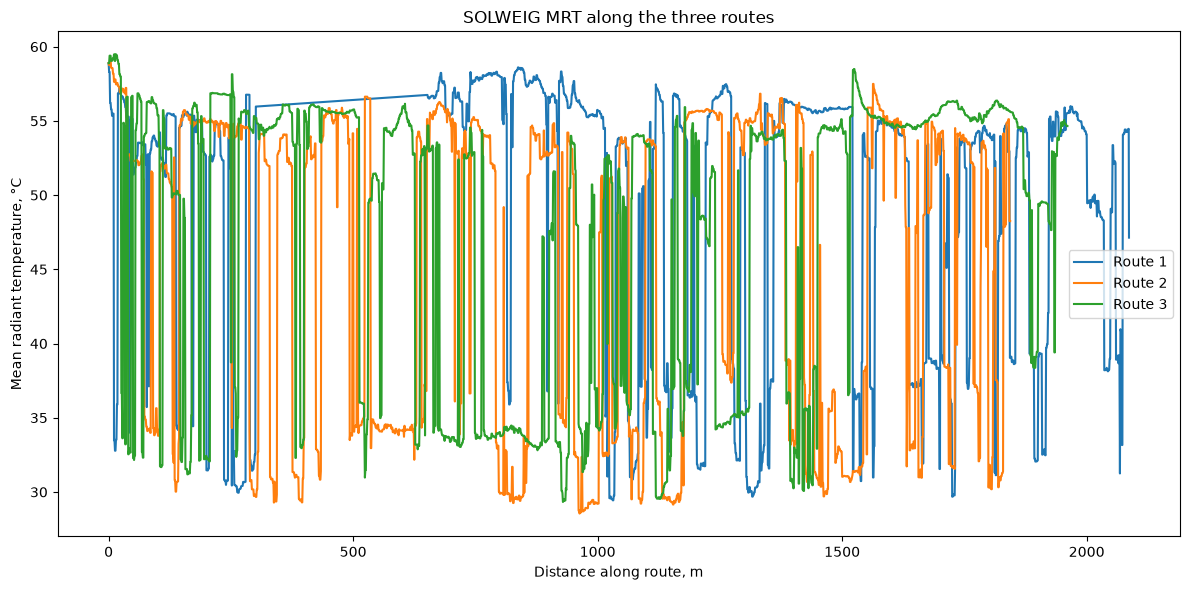

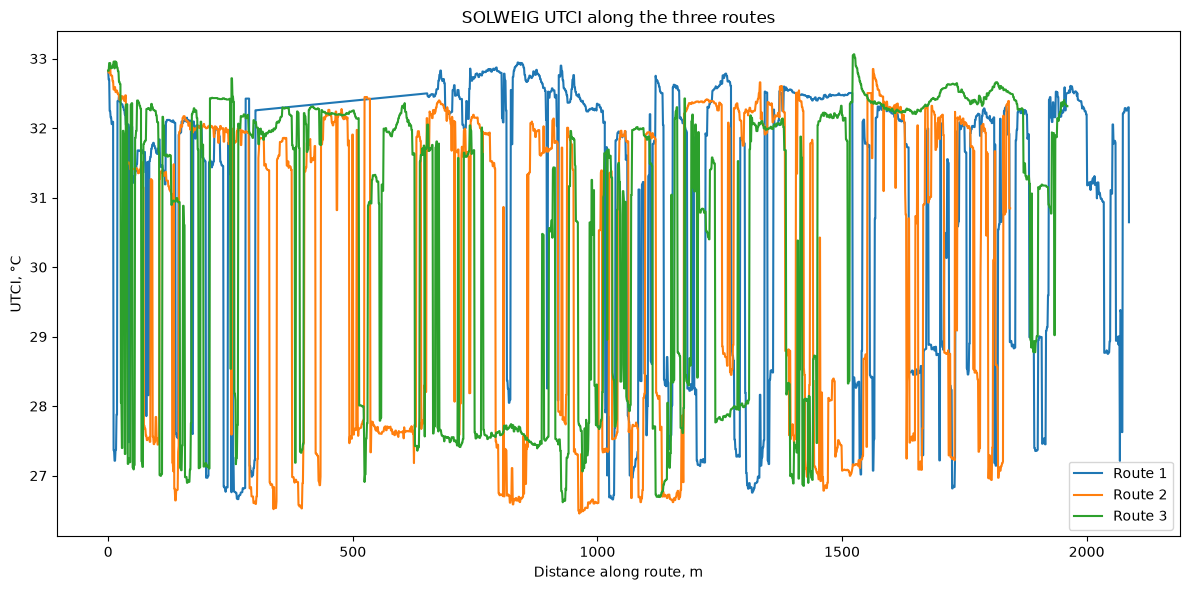

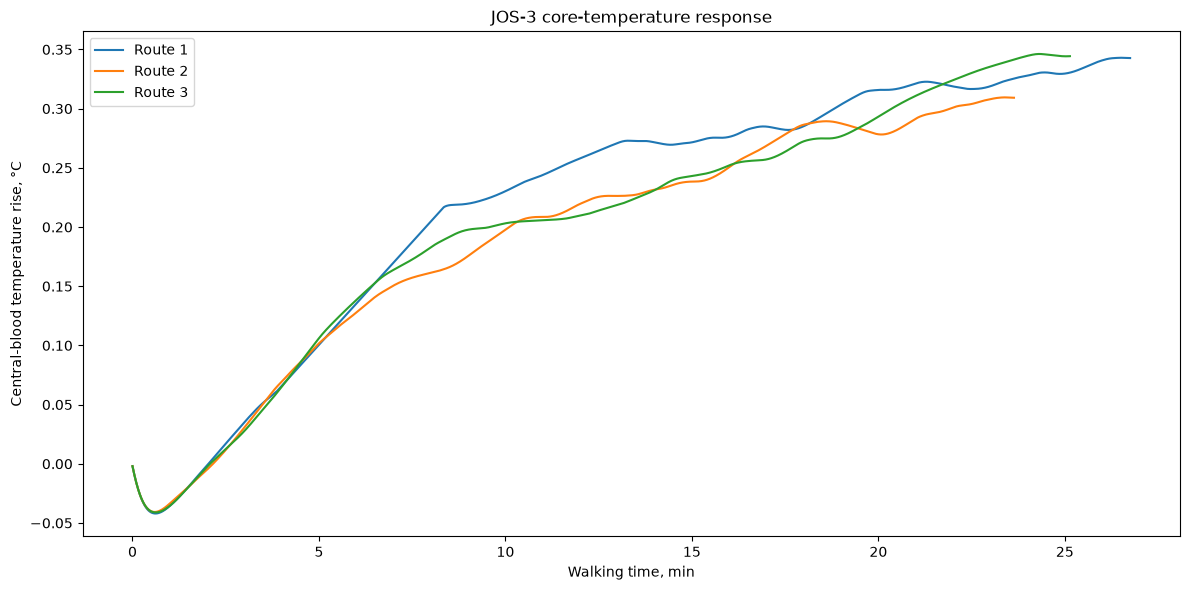

In [41]:
plt.figure(figsize=(12, 6))
for route_id, df in route_results.items():
    plt.plot(df["distance_m"], df["tmrt_c"], label=f"Route {route_id}")
plt.xlabel("Distance along route, m")
plt.ylabel("Mean radiant temperature, °C")
plt.title("SOLWEIG MRT along the three routes")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for route_id, df in route_results.items():
    plt.plot(df["distance_m"], df["utci_c"], label=f"Route {route_id}")
plt.xlabel("Distance along route, m")
plt.ylabel("UTCI, °C")
plt.title("SOLWEIG UTCI along the three routes")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for route_id, df in route_results.items():
    plt.plot(
        df["elapsed_s"] / 60.0,
        df["t_cb_rise_c"],
        label=f"Route {route_id}",
    )
plt.xlabel("Walking time, min")
plt.ylabel("Central-blood temperature rise, °C")
plt.title("JOS-3 core-temperature response")
plt.legend()
plt.tight_layout()
plt.show()

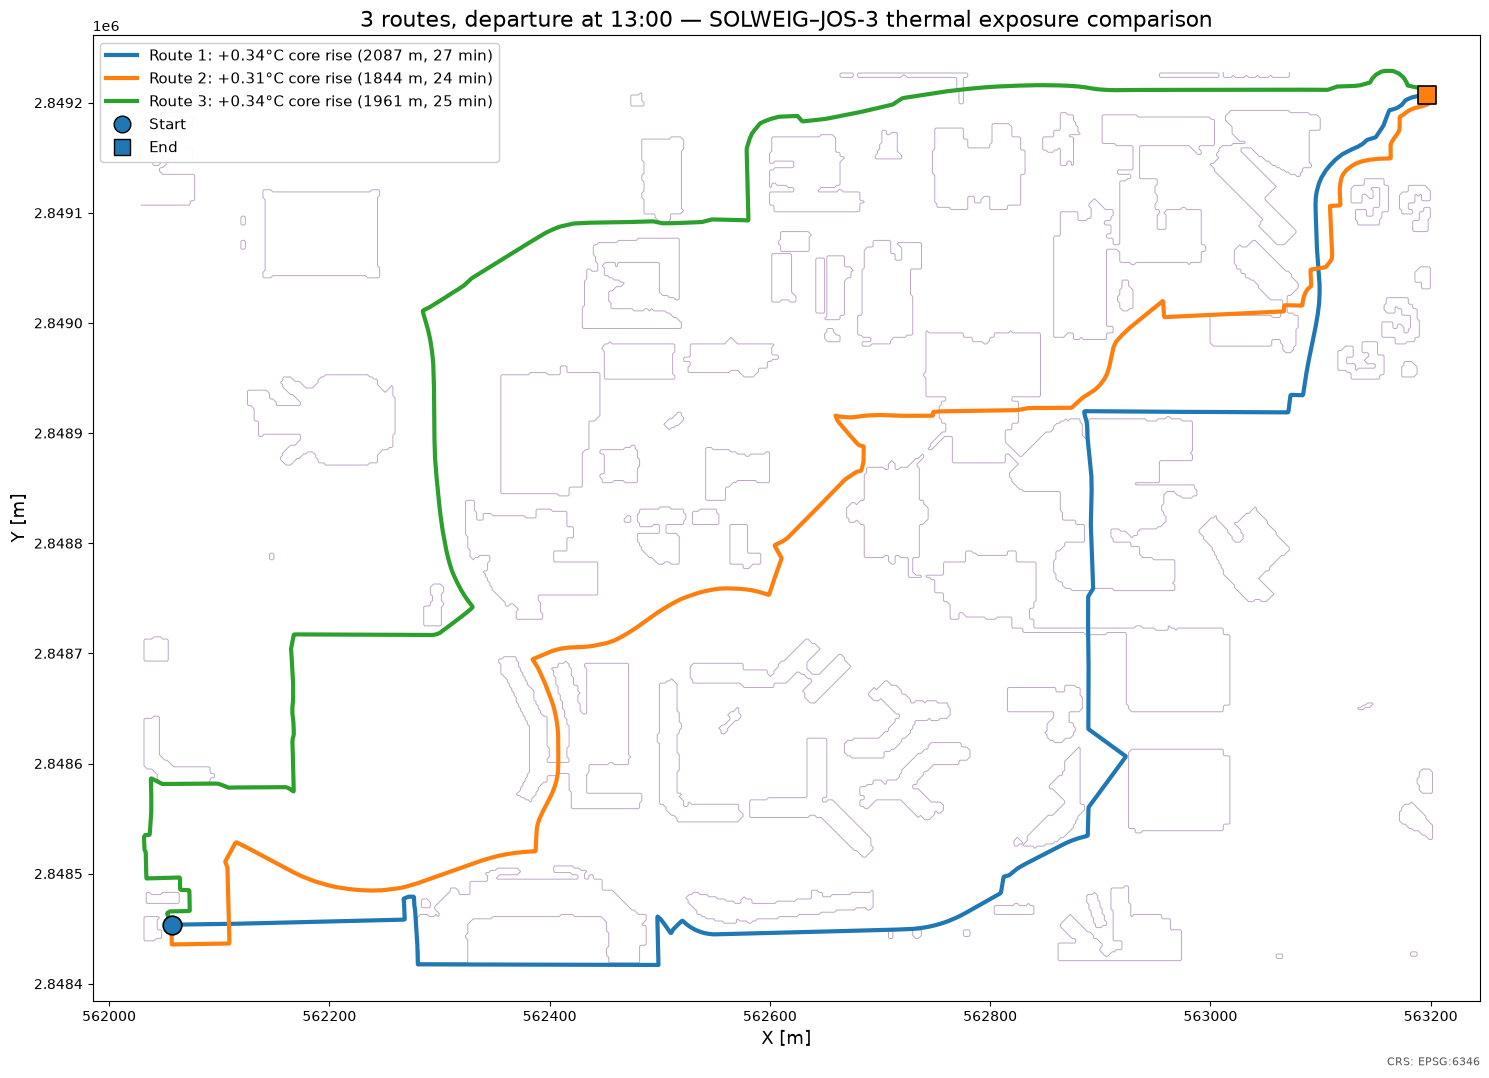

Saved:
/media/harshin/data_drive/solweig/route_results_solweig/routes_core_temperature_rise_map.png
/media/harshin/data_drive/solweig/route_results_solweig/routes_core_temperature_rise_map.pdf


In [42]:
from pathlib import Path

import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# Background building rasters
# ------------------------------------------------------------
DEM_PATH = BASE / "tif" / "dem.tif"
DSM_PATH = BASE / "tif" / "dsm.tif"

MAP_PNG = OUTPUT_DIR / "routes_core_temperature_rise_map.png"
MAP_PDF = OUTPUT_DIR / "routes_core_temperature_rise_map.pdf"

BUILDING_HEIGHT_THRESHOLD_M = 2.0


def load_building_mask(dem_path, dsm_path, threshold_m=2.0):
    with rasterio.open(dem_path) as dem_src:
        dem = dem_src.read(1, masked=True).astype(float)
        transform = dem_src.transform
        bounds = dem_src.bounds
        crs = dem_src.crs

    with rasterio.open(dsm_path) as dsm_src:
        dsm = dsm_src.read(1, masked=True).astype(float)

        if dsm_src.shape != dem.shape:
            raise ValueError("DSM and DEM shapes do not match.")

        if dsm_src.crs != crs:
            raise ValueError("DSM and DEM CRS values do not match.")

        if dsm_src.transform != transform:
            raise ValueError("DSM and DEM transforms do not match.")

    building_height = np.ma.filled(dsm - dem, np.nan)
    building_mask = np.where(
        np.isfinite(building_height)
        & (building_height >= threshold_m),
        1.0,
        0.0,
    )

    # Raster-cell center coordinates for contour plotting
    rows, cols = dem.shape

    x = (
        transform.c
        + (np.arange(cols) + 0.5) * transform.a
    )

    y = (
        transform.f
        + (np.arange(rows) + 0.5) * transform.e
    )

    return building_mask, x, y, bounds, crs


building_mask, raster_x, raster_y, raster_bounds, map_crs = (
    load_building_mask(
        DEM_PATH,
        DSM_PATH,
        BUILDING_HEIGHT_THRESHOLD_M,
    )
)

# ------------------------------------------------------------
# Create map
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(15, 11))

# Light-gray building outlines
ax.contour(
    raster_x,
    raster_y,
    building_mask,
    levels=[0.5],
    linewidths=0.7,
    alpha=0.35,
)

default_colors = (
    plt.rcParams["axes.prop_cycle"]
    .by_key()
    .get("color", [])
)

route_handles = []

for route_number, route_id in enumerate(sorted(route_results)):
    df = route_results[route_id].copy()

    if df.empty:
        continue

    route_color = default_colors[
        route_number % len(default_colors)
    ]

    length_m = float(df["distance_m"].iloc[-1])
    duration_min = float(df["elapsed_s"].iloc[-1]) / 60.0
    final_core_rise = float(df["t_cb_rise_c"].iloc[-1])

    ax.plot(
        df["x"],
        df["y"],
        linewidth=3.0,
        color=route_color,
        solid_capstyle="round",
        zorder=4,
    )

    route_handles.append(
        Line2D(
            [0],
            [0],
            color=route_color,
            linewidth=3.0,
            label=(
                f"Route {route_id}: "
                f"{final_core_rise:+.2f}°C core rise "
                f"({length_m:.0f} m, {duration_min:.0f} min)"
            ),
        )
    )

# ------------------------------------------------------------
# Start and end symbols
# ------------------------------------------------------------
first_route_id = sorted(route_results)[0]
start_df = route_results[first_route_id]

start_x = float(start_df["x"].iloc[0])
start_y = float(start_df["y"].iloc[0])

# All routes are expected to share the same destination.
# Average the final points in case of tiny coordinate differences.
end_x = np.mean([
    float(route_results[route_id]["x"].iloc[-1])
    for route_id in route_results
])

end_y = np.mean([
    float(route_results[route_id]["y"].iloc[-1])
    for route_id in route_results
])

ax.scatter(
    start_x,
    start_y,
    marker="o",
    s=180,
    edgecolors="black",
    linewidths=1.2,
    zorder=8,
)

ax.scatter(
    end_x,
    end_y,
    marker="s",
    s=180,
    edgecolors="black",
    linewidths=1.2,
    zorder=8,
)

start_handle = Line2D(
    [0],
    [0],
    marker="o",
    linestyle="None",
    markersize=12,
    markeredgecolor="black",
    label="Start",
)

end_handle = Line2D(
    [0],
    [0],
    marker="s",
    linestyle="None",
    markersize=12,
    markeredgecolor="black",
    label="End",
)

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
departure_text = DEPARTURE_LOCAL.strftime("%H:%M")

ax.set_title(
    f"{len(route_results)} routes, departure at {departure_text} — "
    "SOLWEIG–JOS-3 thermal exposure comparison",
    fontsize=16,
)

ax.set_xlabel("X [m]", fontsize=13)
ax.set_ylabel("Y [m]", fontsize=13)

ax.set_aspect("equal", adjustable="box")

# Zoom to routes with padding
all_x = np.concatenate([
    df["x"].to_numpy()
    for df in route_results.values()
])

all_y = np.concatenate([
    df["y"].to_numpy()
    for df in route_results.values()
])

padding_x = max(
    0.04 * (all_x.max() - all_x.min()),
    20.0,
)

padding_y = max(
    0.04 * (all_y.max() - all_y.min()),
    20.0,
)

ax.set_xlim(
    all_x.min() - padding_x,
    all_x.max() + padding_x,
)

ax.set_ylim(
    all_y.min() - padding_y,
    all_y.max() + padding_y,
)

ax.legend(
    handles=route_handles + [start_handle, end_handle],
    loc="upper left",
    frameon=True,
    framealpha=0.95,
    fontsize=11,
)

ax.grid(False)

fig.text(
    0.99,
    0.01,
    f"CRS: {map_crs}",
    ha="right",
    va="bottom",
    fontsize=8,
    alpha=0.65,
)

plt.tight_layout()

fig.savefig(
    MAP_PNG,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    MAP_PDF,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(MAP_PNG)
print(MAP_PDF)

## Export SOLWEIG results in `route_utci` comparison format

This section creates three comparison files:

- `routes_points_solweig_all.csv`: every route point, preserving missing SOLWEIG values.
- `routes_points_solweig_valid.csv`: only points with valid MRT and UTCI.
- `routes_points_solweig.csv`: compatibility copy of the valid file.

The section also distinguishes points outside the raster extent from points located inside the extent but on NoData cells. No missing thermal values are replaced or fabricated.


In [43]:
# ============================================================
# Export SOLWEIG route results in route_utci comparison format
# ============================================================

ALL_COMPARISON_CSV = OUTPUT_DIR / "routes_points_solweig_all.csv"
VALID_COMPARISON_CSV = OUTPUT_DIR / "routes_points_solweig_valid.csv"

# Compatibility filename used by the previous workflow.
SOLWEIG_COMPARISON_CSV = OUTPUT_DIR / "routes_points_solweig.csv"

inverse_transformer_comparison = Transformer.from_crs(
    raster_crs,
    source_crs,
    always_xy=True,
)

comparison_tables = []

for route_id in sorted(route_point_tables):
    df = route_point_tables[route_id].copy()

    # Convert projected route coordinates back to longitude/latitude.
    lon_lat = [
        inverse_transformer_comparison.transform(x, y)
        for x, y in zip(df["x"], df["y"])
    ]

    longitude = np.asarray(
        [coordinate[0] for coordinate in lon_lat],
        dtype=float,
    )
    latitude = np.asarray(
        [coordinate[1] for coordinate in lon_lat],
        dtype=float,
    )

    timestamps = pd.to_datetime(df["timestamp"])

    # Decimal local hour, matching the route_utci CSV convention.
    arrival_hour = (
        timestamps.dt.hour
        + timestamps.dt.minute / 60.0
        + timestamps.dt.second / 3600.0
        + timestamps.dt.microsecond / 3.6e9
    )

    route_export = pd.DataFrame({
        "route_id": int(route_id),
        "seq": np.arange(len(df), dtype=int),
        "lat": latitude,
        "lon": longitude,
        "x_proj_m": df["x"].to_numpy(dtype=float),
        "y_proj_m": df["y"].to_numpy(dtype=float),
        "cumdist_m": df["distance_m"].to_numpy(dtype=float),
        "arrival_hour": arrival_hour.to_numpy(dtype=float),
        "tmrt_c": df["tmrt_c"].to_numpy(dtype=float),
        "utci_c": df["utci_c"].to_numpy(dtype=float),
    })

    comparison_tables.append(route_export)

solweig_routes_points = pd.concat(
    comparison_tables,
    ignore_index=True,
)

comparison_columns = [
    "route_id",
    "seq",
    "lat",
    "lon",
    "x_proj_m",
    "y_proj_m",
    "cumdist_m",
    "arrival_hour",
    "tmrt_c",
    "utci_c",
]

if solweig_routes_points.columns.tolist() != comparison_columns:
    raise ValueError(
        "Exported columns do not match the route_utci comparison format."
    )

# ------------------------------------------------------------
# Diagnose missing SOLWEIG values
# ------------------------------------------------------------
missing_thermal = (
    solweig_routes_points["tmrt_c"].isna()
    | solweig_routes_points["utci_c"].isna()
)

# Use the first MRT raster to classify route-point locations.
with rasterio.open(tmrt_catalog.iloc[0]["path"]) as raster_check:
    raster_bounds_check = raster_check.bounds

inside_raster_bounds = (
    (solweig_routes_points["x_proj_m"] >= raster_bounds_check.left)
    & (solweig_routes_points["x_proj_m"] <= raster_bounds_check.right)
    & (solweig_routes_points["y_proj_m"] >= raster_bounds_check.bottom)
    & (solweig_routes_points["y_proj_m"] <= raster_bounds_check.top)
)

solweig_routes_points["inside_raster_bounds"] = inside_raster_bounds
solweig_routes_points["valid_solweig"] = ~missing_thermal
solweig_routes_points["missing_reason"] = np.select(
    [
        ~inside_raster_bounds,
        missing_thermal & inside_raster_bounds,
    ],
    [
        "outside_raster_bounds",
        "inside_bounds_nodata",
    ],
    default="valid",
)

print("SOLWEIG comparison export diagnostics")
print("-------------------------------------")
print("Total route points:", len(solweig_routes_points))
print("Valid thermal points:", int((~missing_thermal).sum()))
print("Missing thermal points:", int(missing_thermal.sum()))
print(
    "Missing outside raster bounds:",
    int((missing_thermal & ~inside_raster_bounds).sum()),
)
print(
    "Missing inside bounds on NoData cells:",
    int((missing_thermal & inside_raster_bounds).sum()),
)

print("\nMissing points by route:")
missing_by_route = (
    solweig_routes_points.loc[missing_thermal]
    .groupby("route_id")
    .size()
)
print(
    missing_by_route
    if not missing_by_route.empty
    else "None"
)

print("\nMissing-distance ranges by route:")
for route_id, group in (
    solweig_routes_points.loc[missing_thermal]
    .groupby("route_id")
):
    print(
        f"Route {route_id}: "
        f"{group['cumdist_m'].min():.2f}–"
        f"{group['cumdist_m'].max():.2f} m"
    )

# ------------------------------------------------------------
# Export complete and validation-ready files
# ------------------------------------------------------------

# Complete file: preserve every route point and its diagnostic flags.
all_export_columns = comparison_columns + [
    "inside_raster_bounds",
    "valid_solweig",
    "missing_reason",
]

solweig_routes_points[
    all_export_columns
].to_csv(
    ALL_COMPARISON_CSV,
    index=False,
    float_format="%.6f",
)

# Validation-ready file: only rows with both MRT and UTCI.
solweig_valid_points = (
    solweig_routes_points.loc[
        solweig_routes_points["valid_solweig"],
        comparison_columns,
    ]
    .copy()
    .reset_index(drop=True)
)

if solweig_valid_points.empty:
    raise ValueError(
        "No valid SOLWEIG route points remain after removing NoData samples."
    )

# Guard against unexpected missing values in the validation file.
required_valid_columns = [
    "x_proj_m",
    "y_proj_m",
    "tmrt_c",
    "utci_c",
]

if solweig_valid_points[required_valid_columns].isna().any().any():
    raise ValueError(
        "The filtered validation file still contains missing values."
    )

solweig_valid_points.to_csv(
    VALID_COMPARISON_CSV,
    index=False,
    float_format="%.6f",
)

# Preserve the previous filename as a copy of the validation-ready dataset.
solweig_valid_points.to_csv(
    SOLWEIG_COMPARISON_CSV,
    index=False,
    float_format="%.6f",
)

print("\nWritten complete CSV:")
print(ALL_COMPARISON_CSV)

print("\nWritten validation-ready CSV:")
print(VALID_COMPARISON_CSV)

print("\nWritten compatibility CSV:")
print(SOLWEIG_COMPARISON_CSV)

print(
    "\nValidation retention:",
    f"{len(solweig_valid_points)}/{len(solweig_routes_points)} "
    f"({100.0 * len(solweig_valid_points) / len(solweig_routes_points):.2f}%)",
)

print("\nValid points by route:")
print(
    solweig_valid_points
    .groupby("route_id")
    .size()
)

print("\nRoute checks for valid comparison points:")
for route_id, group in solweig_valid_points.groupby("route_id"):
    distances = group["cumdist_m"].to_numpy(dtype=float)

    if len(distances) > 1:
        spacing = np.diff(distances)
        median_spacing = float(np.median(spacing))
    else:
        median_spacing = np.nan

    print(
        f"Route {route_id}: "
        f"{len(group)} valid points, "
        f"distance range={distances.min():.2f}–{distances.max():.2f} m, "
        f"median retained spacing={median_spacing:.3f} m, "
        f"MRT={group['tmrt_c'].min():.2f}–"
        f"{group['tmrt_c'].max():.2f} °C, "
        f"UTCI={group['utci_c'].min():.2f}–"
        f"{group['utci_c'].max():.2f} °C"
    )

display(solweig_routes_points.head(10))


SOLWEIG comparison export diagnostics
-------------------------------------
Total route points: 5895
Valid thermal points: 5542
Missing thermal points: 353
Missing outside raster bounds: 353
Missing inside bounds on NoData cells: 0

Missing points by route:
route_id
1    348
3      5
dtype: int64

Missing-distance ranges by route:
Route 1: 303.00–650.00 m
Route 3: 1911.00–1915.00 m

Written complete CSV:
/media/harshin/data_drive/solweig/route_results_solweig/routes_points_solweig_all.csv

Written validation-ready CSV:
/media/harshin/data_drive/solweig/route_results_solweig/routes_points_solweig_valid.csv

Written compatibility CSV:
/media/harshin/data_drive/solweig/route_results_solweig/routes_points_solweig.csv

Validation retention: 5542/5895 (94.01%)

Valid points by route:
route_id
1    1740
2    1845
3    1957
dtype: int64

Route checks for valid comparison points:
Route 1: 1740 valid points, distance range=0.00–2086.50 m, median retained spacing=1.000 m, MRT=29.44–58.89 °C, UTCI

,route_id,seq,lat,lon,x_proj_m,y_proj_m,cumdist_m,arrival_hour,tmrt_c,utci_c,inside_raster_bounds,valid_solweig,missing_reason
0,1,0,25.752796,-80.381212,562056.689312,2.848454e+06,0.0,13.000000,58.887207,32.824944,True,True,valid
1,1,1,25.752796,-80.381202,562057.689225,2.848454e+06,1.0,13.000214,58.296129,32.696820,True,True,valid
2,1,2,25.752796,-80.381192,562058.689138,2.848454e+06,2.0,13.000427,58.295140,32.696816,True,True,valid
3,1,3,25.752796,-80.381182,562059.689051,2.848454e+06,3.0,13.000641,56.214050,32.245909,True,True,valid
4,1,4,25.752797,-80.381172,562060.688964,2.848454e+06,4.0,13.000855,56.213379,32.245974,True,True,valid
5,1,5,25.752797,-80.381162,562061.688877,2.848454e+06,5.0,13.001068,55.780034,32.152411,True,True,valid
6,1,6,25.752797,-80.381152,562062.688791,2.848454e+06,6.0,13.001282,55.779394,32.152481,True,True,valid
7,1,7,25.752797,-80.381142,562063.688704,2.848454e+06,7.0,13.001496,55.339567,32.057539,True,True,valid
8,1,8,25.752797,-80.381132,562064.688617,2.848454e+06,8.0,13.001709,55.338992,32.057623,True,True,valid
9,1,9,25.752797,-80.381122,562065.688530,2.848454e+06,9.0,13.001923,55.491704,32.090863,True,True,valid


## 12. Export pointwise route results

In [44]:
inverse_transformer = Transformer.from_crs(
    raster_crs,
    source_crs,
    always_xy=True,
)

features = []

for route_id, df in route_results.items():
    csv_path = OUTPUT_DIR / f"route_{route_id}_point_results.csv"
    df.to_csv(csv_path, index=False)

    for _, row in df.iterrows():
        lon, lat = inverse_transformer.transform(row["x"], row["y"])

        properties = {
            "route_id": int(route_id),
            "point_index": int(row["point_index"]),
            "distance_m": float(row["distance_m"]),
            "elapsed_s": float(row["elapsed_s"]),
            "timestamp": pd.Timestamp(row["timestamp"]).isoformat(),
            "tmrt_c": float(row["tmrt_c"]),
            "utci_c": float(row["utci_c"]),
            "air_temp_c": float(row["air_temp_c"]),
            "rh_pct": float(row["rh_pct"]),
            "wind_ms": float(row["wind_ms"]),
            "t_cb_c": float(row["t_cb_c"]),
            "t_cb_rise_c": float(row["t_cb_rise_c"]),
            "t_core_mean_c": float(row["t_core_mean_c"]),
            "t_core_mean_rise_c": float(row["t_core_mean_rise_c"]),
        }

        features.append({
            "type": "Feature",
            "geometry": {
                "type": "Point",
                "coordinates": [float(lon), float(lat)],
            },
            "properties": properties,
        })

point_geojson = {
    "type": "FeatureCollection",
    "name": "solweig_route_mrt_utci_jos3",
    "crs": {
        "type": "name",
        "properties": {"name": "urn:ogc:def:crs:OGC:1.3:CRS84"},
    },
    "features": features,
}

(OUTPUT_DIR / "route_point_results.geojson").write_text(
    json.dumps(point_geojson)
)

print("Written outputs:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" ", path.name)

Written outputs:
  route_1_point_results.csv
  route_2_point_results.csv
  route_3_point_results.csv
  route_point_results.geojson
  route_summary.csv
  routes_core_temperature_rise_map.pdf
  routes_core_temperature_rise_map.png
  routes_points_solweig.csv
  routes_points_solweig_all.csv
  routes_points_solweig_valid.csv


## Methodological cautions

- The GeoJSON route metrics from the comparison simulation are not used.
- With hourly SOLWEIG output, MRT and UTCI are linearly interpolated between the surrounding hourly rasters.
- A 5 m route sampling interval is used for JOS-3 to avoid unnecessary sub-second physiological timesteps.
- UTCI is sampled directly from SOLWEIG output.
- JOS-3 central blood temperature (`t_cb`) and spatially averaged core temperature are both exported.
- The JOS-3 result depends strongly on body parameters, clothing, activity, preconditioning, air speed, and meteorological forcing. Report these assumptions explicitly.


- Route points with missing SOLWEIG MRT or UTCI are never replaced with zero or an average. The notebook exports both a complete diagnostic file and a validation-ready file containing only valid SOLWEIG samples.
